# Autoencoder
---

## ¿Qué es un Autoencoder?

Un **autoencoder** es una red neuronal que aprende a comprimir una entrada en una representación de menor dimensión (**espacio latente**) y luego reconstruirla lo más fielmente posible.

Está compuesto por dos partes:
- **Encoder:** reduce la dimensión de la entrada.
- **Decoder:** reconstruye la entrada original desde la representación comprimida.

En este trabajo se aplica un autoencoder sobre caracteres binarios de 7×5 píxeles para:
1. Aprender una representación 2D de los caracteres.
2. Generar nuevos caracteres a partir del espacio latente.
3. Eliminar ruido de imágenes distorsionadas.
4. Explorar el espacio latente con emojis en escala de grises.

---

## 0. Generación del dataset de caracteres (`datos.txt`)

El dataset contiene 32 caracteres (letras mayúsculas A–Z más símbolos) codificados como matrices 7×5 en hexadecimal.  
Esta celda genera el archivo `datos.txt` directamente, sin necesidad de descargarlo por separado.

In [1]:
datos_txt = """
int const Font2[32][7] = {
   {0x0e, 0x11, 0x17, 0x15, 0x17, 0x10, 0x0f},   // 0x40, @
   {0x04, 0x0a, 0x11, 0x11, 0x1f, 0x11, 0x11},   // 0x41, A
   {0x1e, 0x11, 0x11, 0x1e, 0x11, 0x11, 0x1e},   // 0x42, B
   {0x0e, 0x11, 0x10, 0x10, 0x10, 0x11, 0x0e},   // 0x43, C
   {0x1e, 0x09, 0x09, 0x09, 0x09, 0x09, 0x1e},   // 0x44, D
   {0x1f, 0x10, 0x10, 0x1c, 0x10, 0x10, 0x1f},   // 0x45, E
   {0x1f, 0x10, 0x10, 0x1f, 0x10, 0x10, 0x10},   // 0x46, F
   {0x0e, 0x11, 0x10, 0x10, 0x13, 0x11, 0x0f},   // 0x47, G
   {0x11, 0x11, 0x11, 0x1f, 0x11, 0x11, 0x11},   // 0x48, H
   {0x0e, 0x04, 0x04, 0x04, 0x04, 0x04, 0x0e},   // 0x49, I
   {0x1f, 0x02, 0x02, 0x02, 0x02, 0x12, 0x0c},   // 0x4a, J
   {0x11, 0x12, 0x14, 0x18, 0x14, 0x12, 0x11},   // 0x4b, K
   {0x10, 0x10, 0x10, 0x10, 0x10, 0x10, 0x1f},   // 0x4c, L
   {0x11, 0x1b, 0x15, 0x11, 0x11, 0x11, 0x11},   // 0x4d, M
   {0x11, 0x11, 0x19, 0x15, 0x13, 0x11, 0x11},   // 0x4e, N
   {0x0e, 0x11, 0x11, 0x11, 0x11, 0x11, 0x0e},   // 0x4f, O
   {0x1e, 0x11, 0x11, 0x1e, 0x10, 0x10, 0x10},   // 0x50, P
   {0x0e, 0x11, 0x11, 0x11, 0x15, 0x12, 0x0d},   // 0x51, Q
   {0x1e, 0x11, 0x11, 0x1e, 0x14, 0x12, 0x11},   // 0x52, R
   {0x0e, 0x11, 0x10, 0x0e, 0x01, 0x11, 0x0e},   // 0x53, S
   {0x1f, 0x04, 0x04, 0x04, 0x04, 0x04, 0x04},   // 0x54, T
   {0x11, 0x11, 0x11, 0x11, 0x11, 0x11, 0x0e},   // 0x55, U
   {0x11, 0x11, 0x11, 0x11, 0x11, 0x0a, 0x04},   // 0x56, V
   {0x11, 0x11, 0x11, 0x15, 0x15, 0x1b, 0x11},   // 0x57, W
   {0x11, 0x11, 0x0a, 0x04, 0x0a, 0x11, 0x11},   // 0x58, X
   {0x11, 0x11, 0x0a, 0x04, 0x04, 0x04, 0x04},   // 0x59, Y
   {0x1f, 0x01, 0x02, 0x04, 0x08, 0x10, 0x1f},   // 0x5a, Z
   {0x0e, 0x08, 0x08, 0x08, 0x08, 0x08, 0x0e},   // 0x5b, [
   {0x10, 0x10, 0x08, 0x04, 0x02, 0x01, 0x01},   // 0x5c, \\
   {0x0e, 0x02, 0x02, 0x02, 0x02, 0x02, 0x0e},   // 0x5d, ]
   {0x04, 0x0a, 0x11, 0x00, 0x00, 0x00, 0x00},   // 0x5e, ^
   {0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x1f}    // 0x5f, _
   };
"""

with open('datos.txt', 'w', encoding='utf-8') as f:
    f.write(datos_txt)

print("datos.txt generado correctamente.")

datos.txt generado correctamente.


## 1. Carga y procesamiento de los caracteres hexadecimales

Se realiza la lectura y conversión de los caracteres desde `datos.txt`.  
Cada carácter está representado por siete valores hexadecimales (matriz 7×5) y se transforma en una imagen binaria apta para el autoencoder.

La función `cargar_caracteres_hex`:
- Lee el archivo en formato texto.
- Extrae las secuencias numéricas entre llaves `{}`.
- Convierte los valores hexadecimales a binario, representando cada carácter como una matriz de 7 filas y 5 columnas.

Finalmente se obtiene una estructura `numpy` con forma `(32, 7, 5, 1)`.

In [2]:
import re
import numpy as np

def cargar_caracteres_hex(path: str):
    with open(path, 'r', encoding='utf-8') as f:
        texto = f.read()

    grupos = re.findall(r"\{([^{}]+)\}", texto)

    imagenes = []
    for grupo in grupos:
        numeros = [int(x, 16) for x in grupo.split(',') if x.strip()]
        if len(numeros) == 7:
            img = np.zeros((7, 5), dtype=np.float32)
            for fila, valor in enumerate(numeros):
                for col in range(5):
                    img[fila, 4 - col] = (valor >> col) & 1
            imagenes.append(img)

    imagenes = np.array(imagenes, dtype=np.float32)
    return imagenes, (7, 5)


imagenes, (H, W) = cargar_caracteres_hex('datos.txt')
imagenes = np.expand_dims(imagenes, -1)

print("Shape del dataset:", imagenes.shape)

Shape del dataset: (32, 7, 5, 1)


## 2. Construcción del modelo Autoencoder

Se define la arquitectura con **TensorFlow Keras** para obtener una representación comprimida y su posterior reconstrucción.

**Arquitectura:**
- **Encoder:** la entrada `(7, 5, 1)` se aplana (`Flatten`) y pasa por una capa `Dense(64, relu)` antes de comprimirse a un **espacio latente de 2 neuronas**.
- **Decoder:** recibe el vector latente `(2,)`, lo expande con `Dense(64, relu)` y una capa de salida `Dense(H*W, sigmoid)`. La salida se reajusta a `(7, 5, 1)`.
- **Compilación:** optimizador `Adam` y pérdida `binary_crossentropy`, adecuada para píxeles binarios.

In [3]:
from tensorflow.keras import layers, models

# --- Encoder ---
entrada = layers.Input(shape=(H, W, 1))
x = layers.Flatten()(entrada)
x = layers.Dense(64, activation='relu')(x)
latente = layers.Dense(2, name='espacio_latente')(x)
encoder = models.Model(entrada, latente)

# --- Decoder ---
entrada_latente = layers.Input(shape=(2,))
x = layers.Dense(64, activation='relu')(entrada_latente)
x = layers.Dense(H * W, activation='sigmoid')(x)
salida = layers.Reshape((H, W, 1))(x)
decoder = models.Model(entrada_latente, salida)

# --- Autoencoder completo ---
autoencoder = models.Model(entrada, decoder(encoder(entrada)))
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 5, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 2)              │         2,434 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 7, 5, 1)        │         2,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,901 (19.14 KB)

 Trainable params: 4,901 (19.14 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento del Autoencoder

El modelo se entrena usando las mismas imágenes como entrada **y** salida deseada — la red aprende a reconstruirse a sí misma.  
Se seleccionaron **200 épocas** con `batch_size=8`, mezclando los datos en cada época para mejorar la generalización.

In [4]:
historia = autoencoder.fit(
    imagenes, imagenes,
    epochs=200,
    batch_size=8,
    shuffle=True
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6923
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6886 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6848 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6800 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6736 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6655
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6553 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6434 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6313 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6174 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6031 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5902 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5776 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5669 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5567 
Epoch 16/200
4/4 ━━━

## 4. Curva de entrenamiento

La caída sostenida de la pérdida (de ~0.65 a ~0.21) confirma que el modelo aprendió a reconstruir los caracteres progresivamente.

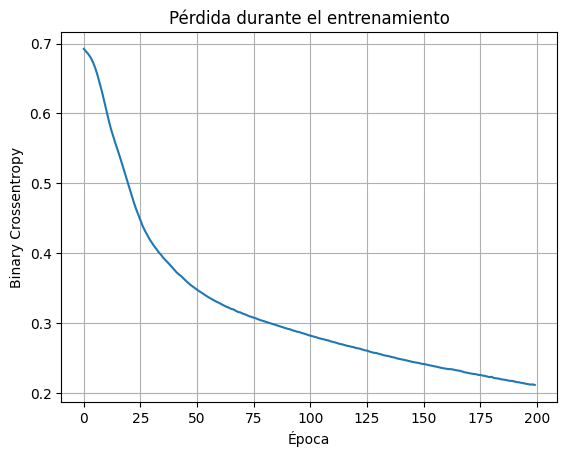

In [5]:
import matplotlib.pyplot as plt

plt.plot(historia.history['loss'])
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Binary Crossentropy')
plt.grid(True)
plt.show()

## 5. Obtención de las etiquetas de los caracteres

Se extraen las etiquetas (caracteres reales) de los comentarios del archivo `datos.txt` usando una expresión regular.

In [6]:
def obtener_etiquetas(path: str):
    with open(path, 'r', encoding='utf-8') as f:
        texto = f.read()
    matches = re.findall(r'//.*,\s*(.)', texto)
    return matches

etiquetas = obtener_etiquetas('datos.txt')
print("Etiquetas:", etiquetas)

Etiquetas: ['@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_']


## 6. Visualización de los caracteres originales

Se visualizan los 32 caracteres del dataset como referencia para comparar con las reconstrucciones del modelo.

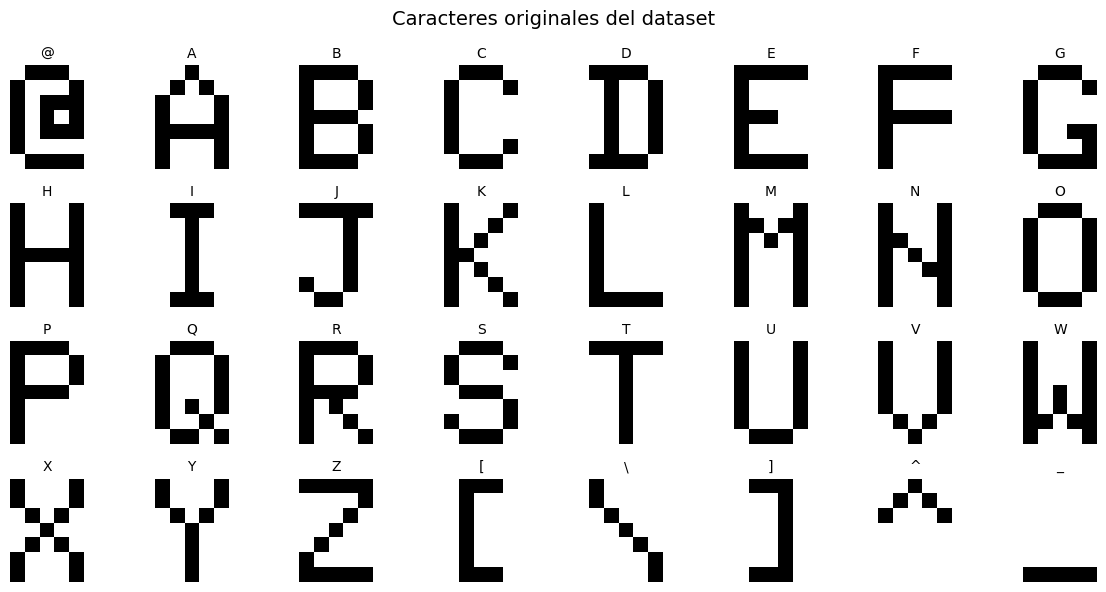

In [7]:
plt.figure(figsize=(12, 6))
for i in range(len(imagenes)):
    plt.subplot(4, 8, i + 1)
    plt.imshow(imagenes[i].squeeze(), cmap='gray_r')
    plt.axis('off')
    plt.title(etiquetas[i], fontsize=10)
plt.suptitle("Caracteres originales del dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Espacio latente y generación de nuevos caracteres

Una vez entrenado el modelo, se visualiza cómo el autoencoder representa cada carácter en su **espacio latente 2D**.
- Los **puntos azules** son las coordenadas latentes de cada carácter original.
- El **punto rojo** es un punto arbitrario `[18, -5]` fuera de la distribución aprendida; el decoder lo convierte en un carácter nuevo.

La organización del espacio demuestra que el modelo capturó relaciones visuales coherentes entre los caracteres.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


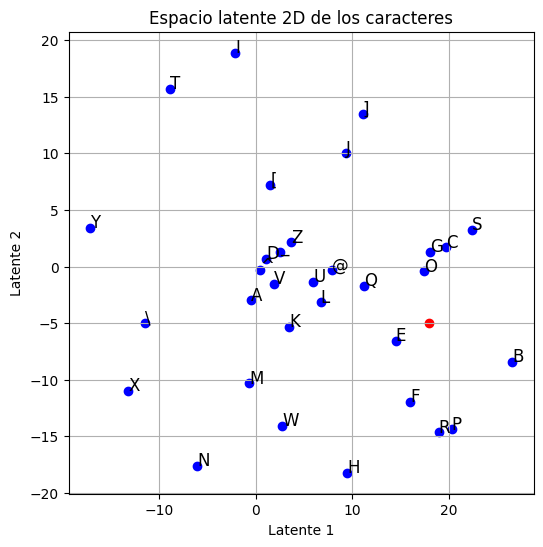

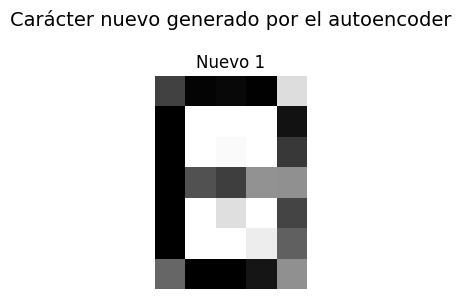

In [8]:
latentes = encoder.predict(imagenes)

nuevo_latente = np.array([[18, -5]])
generados = decoder.predict(nuevo_latente)

# Espacio latente
plt.figure(figsize=(6, 6))
plt.scatter(latentes[:, 0], latentes[:, 1], c='blue')
plt.scatter(nuevo_latente[:, 0], nuevo_latente[:, 1], c='red')
for i, etiqueta in enumerate(etiquetas):
    plt.text(latentes[i, 0] + 0.01, latentes[i, 1] + 0.01, etiqueta, fontsize=12)
plt.title("Espacio latente 2D de los caracteres")
plt.xlabel("Latente 1")
plt.ylabel("Latente 2")
plt.grid(True)
plt.show()

# Carácter generado
plt.figure(figsize=(10, 3))
for i in range(len(generados)):
    plt.subplot(1, len(generados), i + 1)
    plt.imshow(generados[i].squeeze(), cmap='gray_r')
    plt.axis('off')
    plt.title(f"Nuevo {i+1}")
plt.suptitle("Carácter nuevo generado por el autoencoder", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Autoencoder eliminador de ruido (Denoising Autoencoder)

Se implementa una variante que actúa como **eliminador de ruido**.  
La entrada son imágenes distorsionadas con ruido binario aleatorio; la salida esperada son las versiones limpias.  
Así la red aprende a identificar la estructura esencial de cada carácter ignorando las alteraciones.

**Funciones auxiliares:**
- `agregar_ruido`: invierte píxeles aleatoriamente según un nivel de ruido configurable.
- `generador_ruido`: produce lotes de pares (ruidosa, limpia) con niveles de ruido variables para un entrenamiento más robusto.

In [9]:
def agregar_ruido(imagenes, nivel_ruido=0.3):
    imagenes_ruidosas = imagenes.copy()
    n, alto, ancho, canal = imagenes.shape
    mascara = np.random.rand(n, alto, ancho, canal) < nivel_ruido
    imagenes_ruidosas[mascara] = 1 - imagenes_ruidosas[mascara]
    return imagenes_ruidosas


def generador_ruido(imagenes, tamaño_lote=8, repeticiones=100, ruido_min=0.01, ruido_max=0.2):
    total = len(imagenes)
    for _ in range(repeticiones):
        indices = np.random.permutation(total)
        for i in range(0, total, tamaño_lote):
            lote_idx = indices[i:i + tamaño_lote]
            lote_limpio = imagenes[lote_idx]
            nivel_ruido = np.random.uniform(ruido_min, ruido_max)
            lote_ruidoso = agregar_ruido(lote_limpio, nivel_ruido=nivel_ruido)
            yield lote_ruidoso, lote_limpio

### Definición y entrenamiento del modelo denoiser

La arquitectura es idéntica al autoencoder anterior (espacio latente de 2D).  
La diferencia está en el entrenamiento: **entrada = imagen ruidosa**, **salida esperada = imagen limpia**.

In [10]:
from tensorflow.keras import layers, models

# Encoder
entrada_denoiser = layers.Input(shape=(H, W, 1))
x_d = layers.Flatten()(entrada_denoiser)
x_d = layers.Dense(64, activation='relu')(x_d)
latente_d = layers.Dense(2, name='espacio_latente_denoiser')(x_d)
encoder_denoiser = models.Model(entrada_denoiser, latente_d)

# Decoder
entrada_latente_d = layers.Input(shape=(2,))
x_d_dec = layers.Dense(64, activation='relu')(entrada_latente_d)
x_d_dec = layers.Dense(H * W, activation='sigmoid')(x_d_dec)
salida_d = layers.Reshape((H, W, 1))(x_d_dec)
decoder_denoiser = models.Model(entrada_latente_d, salida_d)

# Modelo completo
eliminador_ruido = models.Model(
    entrada_denoiser,
    decoder_denoiser(encoder_denoiser(entrada_denoiser))
)
eliminador_ruido.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento con generador
gen_ruido = generador_ruido(imagenes, tamaño_lote=8, repeticiones=100)
pasos_por_epoca = len(imagenes) // 8

eliminador_ruido.fit(
    gen_ruido,
    steps_per_epoch=pasos_por_epoca,
    epochs=600
)

Epoch 1/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6946
Epoch 2/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6933
Epoch 3/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6875
Epoch 4/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6835
Epoch 5/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6778
Epoch 6/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6720
Epoch 7/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6635
Epoch 8/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6572
Epoch 9/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6462
Epoch 10/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6370
Epoch 11/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6227
Epoch 12/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6168
Epoch 13/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6069
Epoch 14/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5991
Epoch 15/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5948
Epoch 16/600
4/4 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 108/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3871 
Epoch 109/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3798 
Epoch 110/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3726 
Epoch 111/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3658
Epoch 112/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3595 
Epoch 113/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3535 
Epoch 114/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3477 
Epoch 115/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3422 
Epoch 116/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3370 
Epoch 117/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3320 
Epoch 118/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3274 
Epoch 119/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3231 
Epoch 120/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3191 
Epoch 121/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3154 
Epoch 122/600
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3

### Evaluación: Original vs. Ruidosa vs. Reconstruida

Se aplica ruido a los primeros 8 caracteres con dos niveles distintos y se comparan tres filas:
1. **Original** — sin ruido.
2. **Ruidosa** — con ruido añadido.
3. **Limpia** — reconstrucción del denoiser (umbralizada a 0.5).

**Conclusión:** el modelo funcionó bien para ruido bajo (~5–10%). Con 30% de ruido (~11 de 35 píxeles invertidos), la estructura del carácter cambia demasiado y la reconstrucción se degrada. Esto se explica por el tamaño reducido del dataset (32 muestras), que lleva al modelo a memorizar en lugar de generalizar.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


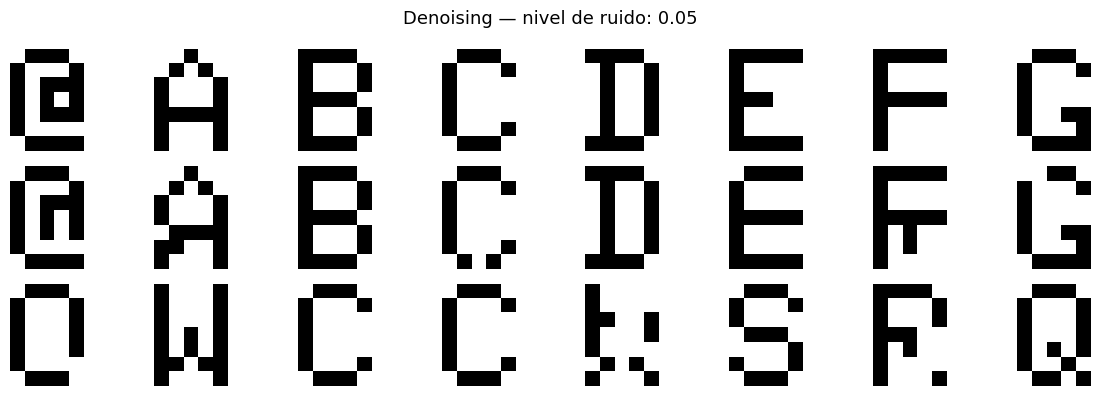

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


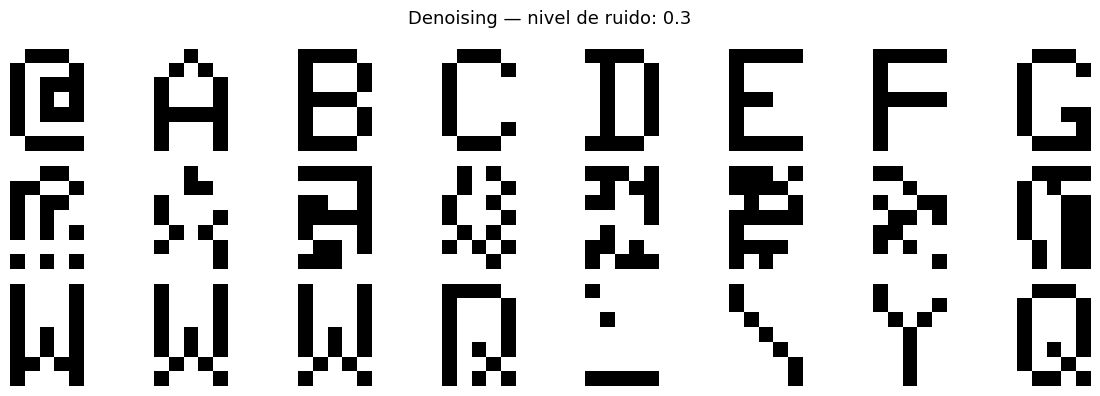

In [11]:
for nivel in [0.05, 0.3]:
    imagenes_prueba_ruidosas = agregar_ruido(imagenes[:8], nivel_ruido=nivel)
    imagenes_limpias = eliminador_ruido.predict(imagenes_prueba_ruidosas)

    plt.figure(figsize=(12, 4))
    for i in range(8):
        plt.subplot(3, 8, i + 1)
        plt.imshow(imagenes[i].squeeze(), cmap='gray_r')
        plt.axis('off')
        if i == 0: plt.ylabel("Original", fontsize=9)

        plt.subplot(3, 8, 8 + i + 1)
        plt.imshow(imagenes_prueba_ruidosas[i].squeeze(), cmap='gray_r')
        plt.axis('off')
        if i == 0: plt.ylabel("Ruidosa", fontsize=9)

        plt.subplot(3, 8, 16 + i + 1)
        plt.imshow((imagenes_limpias[i] > 0.5).squeeze(), cmap='gray_r')
        plt.axis('off')
        if i == 0: plt.ylabel("Limpia", fontsize=9)

    plt.suptitle(f"Denoising — nivel de ruido: {nivel}", fontsize=13)
    plt.tight_layout()
    plt.show()